In this notebook, we will present the two-Stock replication in Cover's Original paper. 
Specifically, Cover used a two-stock example over a 20-year period and compared the wealth paths of these two stocks with a constant rebalanced portfolio, and showed how the Universal Portfolio weights changed over time.

We do the experiment twice. First we choose `AAPL` and `KO`. And then we choose `BA` and `PG.`
The time horizon we use is from 2006 to 2026. 

I tried two different stock pairs because the first pair did not closely resemble the pattern shown in Cover's original paper. This motivated me to test whether another pair of stocks would produce a more similar result.

In [ ]:
using CSV
using DataFrames
using LinearAlgebra
using Plots
using Revise
includet("../src.jl")

println(pwd())
println(readdir(".."))
df = CSV.read("../dataset/prices_6stocks_20years.csv", DataFrame)
prices= Matrix{Float64}(df[:,2:end])

println("prices size = ", size(prices))

c:\Users\Odysseus\GR6104_homework\final_proj\notebooks
["README.md", "dataset", "notebooks", "src.jl", "unit_test"]
prices size = (5031, 6)
[2.669642925262451 26.84000015258789 20.450000762939453 15.40999984741211 70.44000244140625 58.779998779296875; 2.677500009536743 26.969999313354492 20.40999984741211 15.4399995803833 71.16999816894531 58.88999938964844; 2.6564290523529053 26.989999771118164 20.510000228881836 15.229999542236328 70.33000183105469 58.70000076293945; 2.7249999046325684 26.90999984741211 20.704999923706055 15.293333053588867 69.3499984741211 58.63999938964844; 2.7160708904266357 26.860000610351562 20.80500030517578 15.236666679382324 68.7699966430664 59.08000183105469]


# We select two stocks: `AAPL` and `KO`

In [12]:
stock1_name= "AAPL"
stock2_name= "KO"
prices_2= Matrix{Float64}(df[:,[stock1_name, stock2_name]])

# We use `simplex_grid_md` in src.jl, let eta =0.01 to generate a simplex grid for 
# two-stocks
grid= simplex_grid_md(2, 0.01)
b1_grid= Float64[] 
crp_final_wealths=Float64[]# Store our final wealth of each CRP portfolio.

for b in grid
    wealth= crp_func(prices_2, b)
    push!(b1_grid,b[1])  
    push!(crp_final_wealths, wealth[end])
end

# Universal Portfolio final wealth
eta= 0.01
up_wealth_2,b_weights_2,S_grid_2=uni_port_func(prices_2,eta)
up_final_2=up_wealth_2[end]

# Best CRP, we use `bcrp_func_md` in `src.jl`
best_b,best_crp_wealth,best_wealth_set= bcrp_func_md(prices_2, eta)
best_b1 = best_b[1]

# Compute the buy-and-hold wealth path for each individual stock.
stock1_wealth= prices_2[:, 1]./prices_2[1, 1] # We do normalization first
stock2_wealth= prices_2[:, 2]./prices_2[1, 2]
best_individual_wealth= max(stock1_wealth[end], stock2_wealth[end]) 

println("Best CRP weight in AAPL =",best_b1)
println("Best CRP final wealth = ",best_crp_wealth)
println("Best individual stock wealth = ",best_individual_wealth)
#we can define rebalancing gain as the ratio between
# the BCRP final wealth and the best individual final wealth.
println("Rebalancing gain= ",best_crp_wealth/best_individual_wealth)

Best CRP weight in AAPL =1.0
Best CRP final wealth = 101.83383806837598
Best individual stock wealth = 101.83383806837617
Rebalancing gain= 0.9999999999999982


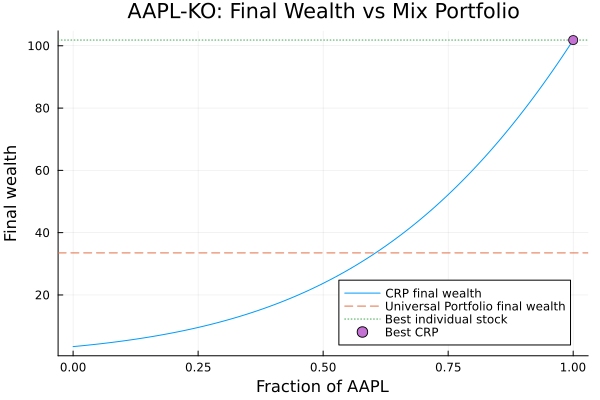

In [14]:
p2= plot(b1_grid,crp_final_wealths,label ="CRP final wealth",
    xlabel= "Fraction of AAPL",ylabel = "Final wealth",
    title = "AAPL-KO: Final Wealth vs Mix Portfolio")
hline!(p2,[up_final_2],label= "Universal Portfolio final wealth",linestyle=:dash)
hline!(p2,[best_individual_wealth],label="Best individual stock",linestyle =:dot)
scatter!(p2,[best_b1],[best_crp_wealth],label="Best CRP",markersize = 5)

savefig(p2, "AAPL_KO_final_wealth_vs_mix.png")
display(p2)

In this experiment, the best CRP assigns 100% weight to AAPL. This means the best crp in hindsight is to to simply holding AAPL over the whole period. 

The rebalancing gain is almost 1, which means daily rebalancing does not provide additional benefit for this stock pair. In order to gain Cover's results, i.e. we can earn money from rebalancing, we choose another set of stocks.

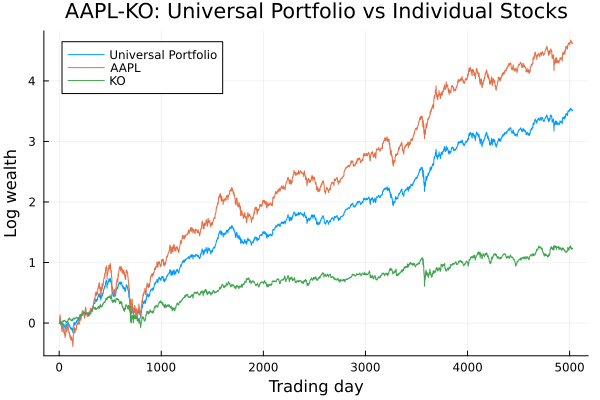

In [17]:
# Plot the log-wealth trajectory of the Universal Portfolio
#we use log to make long-term growth easier to compare
p3_log = plot(log.(up_wealth_2),label ="Universal Portfolio",xlabel = "Trading day",
    ylabel ="Log wealth",title = "AAPL-KO: Universal Portfolio vs Individual Stocks")
plot!(p3_log,log.(stock1_wealth),label = stock1_name)
plot!(p3_log,log.(stock2_wealth),label = stock2_name)

savefig(p3_log, "AAPL_KO_universal_vs_individual_stocks_log.png")
display(p3_log)

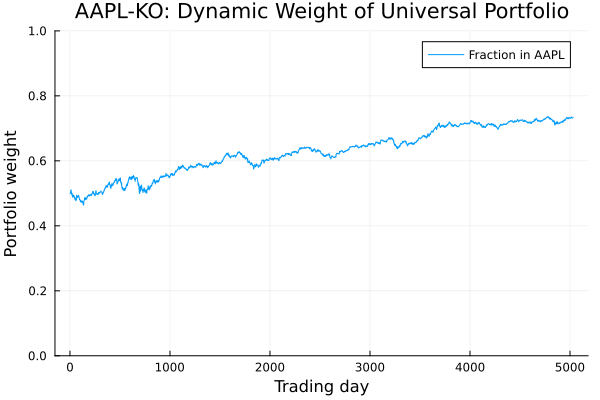

In [19]:
# We will see how the Universal Portfolio weights changed over time.
p4 =plot(b_weights_2[:, 1],label ="Fraction in $(stock1_name)",xlabel = "Trading day",
    ylabel= "Portfolio weight",title = "AAPL-KO: Dynamic Weight of Universal Portfolio",
    ylim= (0, 1))
savefig(p4,"AAPL_KO_dynamic_weight.png")
display(p4)